In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms

In [2]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [26]:
device

device(type='cuda')

In [3]:
image_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2,contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229, 0.224, 0.225])
])

In [6]:
from torchvision import datasets

path = "/kaggle/input/datasets/rishisingh07/rishi-dl/dataset"

dataset = datasets.ImageFolder(root=path,transform=image_transform)

print(len(dataset))

2300


In [7]:
dataset.classes

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [8]:
num_classes=len(dataset.classes)
num_classes

6

In [10]:
train_size=int(0.75*len(dataset))
test_size=len(dataset)-train_size

In [11]:
train_size , test_size

(1725, 575)

In [12]:
from torch.utils.data import random_split

In [13]:
 train_dataset , test_dataset= random_split(dataset,[train_size,test_size])


In [14]:
len(train_dataset) , len(test_dataset)

(1725, 575)

In [15]:
from torch.utils.data import DataLoader
## Now we will be creating the train loader and test loader 
train_loader=DataLoader(train_dataset, batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False)


In [16]:
for images , labels in train_loader:
    print(images.shape , labels.shape)
    break

torch.Size([32, 3, 224, 224]) torch.Size([32])


In [40]:
labels[0]

tensor(1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..1.5593902].


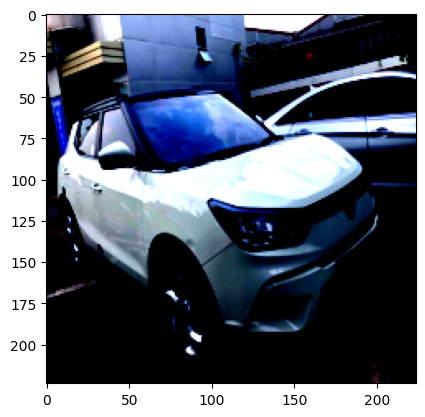

In [17]:
import matplotlib.pyplot as plt
plt.imshow(images[0].permute(1,2,0)) #yTorch uses (C, H, W) format Matplotlib uses (H, W, C) format permute(1,2,0) converts tensor shape for proper visualization
plt.show()

In [18]:
class CarClassifierCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network=nn.Sequential(
            nn.Conv2d(3,16,kernel_size=(3,3),stride=1,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2),stride=(2,2),padding=0),
            nn.Conv2d(16,32,kernel_size=(3,3),stride=1,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2),stride=(2,2),padding=0), #(32,56,56)
            nn.Conv2d(32,64,kernel_size=(3,3),stride=1,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2),stride=(2,2),padding=0), #(64,28,28)
            nn.Flatten(),
            nn.Linear(64*28*28,512),
            nn.ReLU(),
            nn.Linear(512,num_classes),
        )
    def forward(self,x):
       return self.network(x);

In [19]:
import torch.optim as optim
model=CarClassifierCNN(num_classes=num_classes).to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

In [20]:
def train_model(model, criterion, optimizer, train_loader, num_of_epochs=5):
    model.train()
    
    for epoch in range(num_of_epochs):
        running_loss = 0.0
        
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            # Forward pass
            train_prediction = model(images)   # ❗ pass input 
            
            # Loss calculation
            loss = criterion(train_prediction, labels)
            
            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Accumulate loss
            running_loss += loss.item() * images.size(0)
        
        # Epoch loss
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch: {epoch+1}/{num_of_epochs}, Loss: {epoch_loss:.4f}")


In [21]:
train_model(model, criterion, optimizer, train_loader,10)

Epoch: 1/10, Loss: 1.9945
Epoch: 2/10, Loss: 1.4219
Epoch: 3/10, Loss: 1.2198
Epoch: 4/10, Loss: 1.1276
Epoch: 5/10, Loss: 1.0694
Epoch: 6/10, Loss: 0.9980
Epoch: 7/10, Loss: 0.9450
Epoch: 8/10, Loss: 0.8643
Epoch: 9/10, Loss: 0.8347
Epoch: 10/10, Loss: 0.7972


In [22]:
from sklearn.metrics import accuracy_score

def evaluate_model(model, test_loader):
    model.eval()
    
    all_labels = []
    all_predicted = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(images)
            
            # Get predicted class
            _, predicted = torch.max(outputs, 1)
            
            # Store results
            all_labels.extend(labels.cpu().numpy())
            all_predicted.extend(predicted.cpu().numpy())
    
    # Compute accuracy AFTER loop
    acc_score = accuracy_score(all_labels, all_predicted)
    print(f"Validation Accuracy: {acc_score * 100:.2f}%")


            

In [23]:
evaluate_model(model,test_loader)

Validation Accuracy: 56.52%


So we can see our training loss is reduced to the 0.7972 but our validation accuracy is arround 56.52% it is clearly showing the case of overfiting.


CNN With Regurlarization

In [24]:
class CarClassifierCNNRegulartiztion(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.network=nn.Sequential(
            nn.Conv2d(3,16,kernel_size=(3,3),stride=1,padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.MaxPool2d(kernel_size=(2,2),stride=(2,2),padding=0),
            nn.Conv2d(16,32,kernel_size=(3,3),stride=1,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2),stride=(2,2),padding=0), #(32,56,56)
            nn.Conv2d(32,64,kernel_size=(3,3),stride=1,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2),stride=(2,2),padding=0), #(64,28,28)
            nn.Flatten(),
            nn.Linear(64*28*28,512),
            nn.Dropout(0.5),
            nn.ReLU(),
            nn.Linear(512,num_classes),
        )
    def forward(self,x):
        return self.network(x)

In [25]:
model_with_regularization=CarClassifierCNNRegulartiztion(num_classes).to(device)
optimizer_with_regularization=optim.Adam(model_with_regularization.parameters(),lr=0.001,weight_decay=1e-4)

In [26]:
train_model(model_with_regularization,criterion, optimizer_with_regularization, train_loader,10)

Epoch: 1/10, Loss: 8.7333
Epoch: 2/10, Loss: 1.5161
Epoch: 3/10, Loss: 1.4042
Epoch: 4/10, Loss: 1.3232
Epoch: 5/10, Loss: 1.3348
Epoch: 6/10, Loss: 1.2626
Epoch: 7/10, Loss: 1.2079
Epoch: 8/10, Loss: 1.1799
Epoch: 9/10, Loss: 1.1710
Epoch: 10/10, Loss: 1.1435


In [27]:
evaluate_model(model_with_regularization,test_loader)

Validation Accuracy: 52.70%


We got the validation accuracy as 52.70% so since it is poor compared to the above model

Training with pretrained Model

In [30]:
import torchvision.models as models

Model Training with efficient net

In [31]:
class CarClassifierEfficientNet(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.model=models.efficientnet_b0(weights='DEFAULT')
        for param in self.model.parameters(): 
            param.requires_grad=False
        in_features=self.model.classifier[1].in_features 
        self.model.classifier[1]=nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features,num_classes))
    def forward(self,x):
        return self.model(x)

In [32]:
model_efficentnet= CarClassifierEfficientNet(num_classes).to(device)
optimizer_efficientnet=optim.Adam(filter(lambda p: p.requires_grad , model_efficentnet.parameters()),lr=0.001)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 131MB/s]


In [33]:
train_model(model_efficentnet,criterion,optimizer_efficientnet, train_loader,10)

Epoch: 1/10, Loss: 1.5379
Epoch: 2/10, Loss: 1.2136
Epoch: 3/10, Loss: 1.0732
Epoch: 4/10, Loss: 1.0243
Epoch: 5/10, Loss: 0.9715
Epoch: 6/10, Loss: 0.9560
Epoch: 7/10, Loss: 0.9172
Epoch: 8/10, Loss: 0.9198
Epoch: 9/10, Loss: 0.8833
Epoch: 10/10, Loss: 0.8986


In [34]:
evaluate_model(model_efficentnet,test_loader)

Validation Accuracy: 63.65%


As we can see here we have oberved the validation accuracy of 63.65%  these are better compared to the cnn models

In [35]:
from torchvision import models
class CarClassifierResNet(nn.Module):
    def __init__(self,num_classes,dropout=0.5):
        super().__init__()
        self.model=models.resnet50(weights="DEFAULT")
        ## we will freeze all the layers
        for params in self.model.parameters():
            params.requires_grad=False
        ## we will unfreeze the layer 4
        for params in self.model.layer4.parameters():
            params.requires_grad=True
        self.model.fc=nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(self.model.fc.in_features,num_classes))
    def forward(self,x):
            return self.model(x) 
        
        

In [36]:
model_resnet= CarClassifierResNet(num_classes).to(device)
optimizer_resnet=optim.Adam(filter(lambda p: p.requires_grad , model_resnet.parameters()),lr=0.001)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 155MB/s] 


In [37]:
train_model(model_resnet,criterion,optimizer_resnet, train_loader,10)

Epoch: 1/10, Loss: 0.9054
Epoch: 2/10, Loss: 0.5327
Epoch: 3/10, Loss: 0.4003
Epoch: 4/10, Loss: 0.2735
Epoch: 5/10, Loss: 0.2366
Epoch: 6/10, Loss: 0.2137
Epoch: 7/10, Loss: 0.1367
Epoch: 8/10, Loss: 0.1282
Epoch: 9/10, Loss: 0.1662
Epoch: 10/10, Loss: 0.1008


In [38]:
evaluate_model(model_resnet,test_loader)

Validation Accuracy: 79.13%


So as we can see that the validation accuracy of the Resnet pretrained model is 79.13%

In [39]:
import optuna

So here we can see that the Resnet has better validation accuracy compared to efficent net

In [40]:
def objective(trial):

    # ✅ FIX for Subset
    num_classes = len(train_dataset.dataset.classes)

    # Hyperparameters
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    
    dropout = trial.suggest_float("dropout", 0.2, 0.7)
    

   

    # Model
    model = CarClassifierResNet(num_classes=num_classes, dropout=dropout).to(device)

    # Loss + Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # -------- Training --------
    for epoch in range(3):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # -------- Validation --------
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_accuracy = correct / total
    return val_accuracy


# Run Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

[I 2026-05-02 14:12:29,743] A new study created in memory with name: no-name-1fe12819-3c61-43a3-920e-f4b6702da0ac
[I 2026-05-02 14:14:16,959] Trial 0 finished with value: 0.7634782608695653 and parameters: {'lr': 0.00045384640586853956, 'dropout': 0.6424284197055247}. Best is trial 0 with value: 0.7634782608695653.
[I 2026-05-02 14:15:54,394] Trial 1 finished with value: 0.7617391304347826 and parameters: {'lr': 0.0002502609925392609, 'dropout': 0.2789700047670815}. Best is trial 0 with value: 0.7634782608695653.
[I 2026-05-02 14:17:30,740] Trial 2 finished with value: 0.4991304347826087 and parameters: {'lr': 1.962440281517385e-05, 'dropout': 0.5025379050489232}. Best is trial 0 with value: 0.7634782608695653.
[I 2026-05-02 14:19:06,736] Trial 3 finished with value: 0.7634782608695653 and parameters: {'lr': 0.00022226185577979275, 'dropout': 0.671168193718044}. Best is trial 0 with value: 0.7634782608695653.
[I 2026-05-02 14:20:42,419] Trial 4 finished with value: 0.7721739130434783 a

In [41]:
study.best_params

{'lr': 0.0006027446709905322, 'dropout': 0.6153251633150144}

In [42]:
class CarClassifierResNetupdated(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.model=models.resnet50(weights="DEFAULT")
        ## we will freeze all the layers
        for params in self.model.parameters():
            params.requires_grad=False
        ## we will unfreeze the layer 4
        for params in self.model.layer4.parameters():
            params.requires_grad=True
        self.model.fc=nn.Sequential(
            nn.Dropout( 0.6153251633150144),
            nn.Linear(self.model.fc.in_features,num_classes))
    def forward(self,x):
            return self.model(x) 

In [43]:
model_resnetup= CarClassifierResNetupdated(num_classes).to(device)
optimizer_resnetup=optim.Adam(filter(lambda p: p.requires_grad , model_resnetup.parameters()),lr= 0.0006027446709905322)

In [47]:
train_model(model_resnetup,criterion,optimizer_resnetup, train_loader,10)

Epoch: 1/10, Loss: 0.0886
Epoch: 2/10, Loss: 0.0806
Epoch: 3/10, Loss: 0.0792
Epoch: 4/10, Loss: 0.0696
Epoch: 5/10, Loss: 0.0668
Epoch: 6/10, Loss: 0.0595
Epoch: 7/10, Loss: 0.0662
Epoch: 8/10, Loss: 0.0835
Epoch: 9/10, Loss: 0.0466
Epoch: 10/10, Loss: 0.0441


In [48]:
evaluate_model(model_resnetup,test_loader)

Validation Accuracy: 80.70%


So we can got the accuracy of the 80.70%

In [49]:
from sklearn.metrics import classification_report
model_resnetup.eval()
    
all_labels = []
all_predicted = []
    
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
            
        # Forward pass
        outputs = model_resnetup(images)
            
        # Get predicted class
        _, predicted = torch.max(outputs, 1)
        # Store results
        all_labels.extend(labels.cpu().numpy())
        all_predicted.extend(predicted.cpu().numpy())
        
            

In [53]:
cr=classification_report(all_labels,all_predicted)
print(cr)

              precision    recall  f1-score   support

           0       0.86      0.85      0.85       128
           1       0.69      0.73      0.71        91
           2       0.86      0.89      0.88       121
           3       0.67      0.74      0.70        77
           4       0.67      0.61      0.64        79
           5       0.79      0.71      0.75        79

    accuracy                           0.77       575
   macro avg       0.76      0.75      0.75       575
weighted avg       0.77      0.77      0.77       575



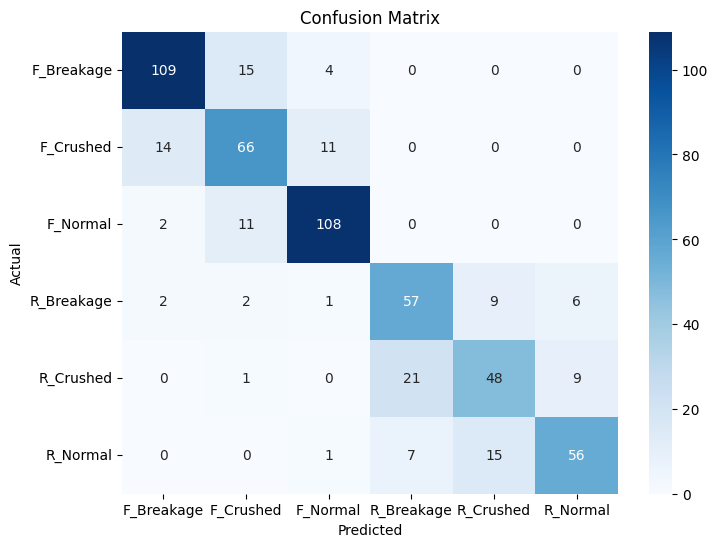

In [54]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(all_labels,all_predicted)
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',  xticklabels=dataset.classes,
            yticklabels=dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [56]:
import torch

torch.save(model_resnetup.state_dict(), "/kaggle/working/model_resnetup.pth")